# Project B — Data Preprocessing, end to end

Everything between the two downloaded datasets and model-ready arrays.

**Inputs**
- `data/raw/pulsedb/*.mat` — 5 PulseDB VitalDB subsets, 18 GB, ECG + PPG + ABP at 125 Hz
- `data/raw/ppg_dalia/data.zip` → `data/processed/ppg_dalia/S*.npz` — 15 free-living subjects

**Outputs**
- `data/processed/pulsedb/<split>/` — `signals.npy`, `labels.npy`, `subjects.npy`, `meta.parquet`
- `data/processed/ppg_dalia/windows/` — the same shape, so a PulseDB-trained model runs on it unchanged
- `splits/manifest.json` — which subject sits in which split, with the leakage assertions
- `results/figures/*.png`

Re-running is cheap: every build step skips work that is already on disk. Delete the
output directory to force a rebuild.

In [1]:
import sys, os, json, time, shutil, glob
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from paths import (ROOT, RAW_PULSEDB, PULSEDB_SUBSETS, PROC_PULSEDB,
                   PROC_DALIA, SPLITS, RESULTS, FEATURES)
from pulsedb_loader import PulseDBSubset
import preprocess as pp
import viz

viz.use_style()
FIG = RESULTS / "figures"; FIG.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    p = FIG / name
    fig.savefig(p)
    print("saved", p.relative_to(ROOT))
    return p

def free_gb():
    s = os.statvfs(ROOT)
    return s.f_bavail * s.f_frsize / 1e9

print(f"python {sys.version.split()[0]} | numpy {np.__version__} | disk free {free_gb():.1f} GB")

python 3.13.5 | numpy 2.1.3 | disk free 11.1 GB


---
## 1. What we actually have

Two datasets doing two different jobs. PulseDB has BP labels and supplies training and
honest testing. PPG-DaLiA has no BP labels at all — it is the free-living stress test
for a model trained on ICU data.

In [2]:
rows = []
for name, path in PULSEDB_SUBSETS.items():
    s = PulseDBSubset(str(path))
    rows.append(dict(dataset="PulseDB", split=name, segments=s.n,
                     subjects=len(s.subjects),
                     seg_per_subj=s.n // len(s.subjects),
                     sbp=f"{s.sbp.mean():.0f}±{s.sbp.std():.0f}",
                     dbp=f"{s.dbp.mean():.0f}±{s.dbp.std():.0f}",
                     age_median=float(np.nanmedian(s.age)),
                     gb=path.stat().st_size/1e9))
    s.close()
inv = pd.DataFrame(rows)
print(inv.to_string(index=False))
print(f"\nPulseDB total: {inv.segments.sum():,} segments, "
      f"{inv.segments.sum()*10/3600:,.0f} hours, {inv.gb.sum():.1f} GB on disk")

dataset         split  segments  subjects  seg_per_subj    sbp   dbp  age_median        gb
PulseDB         train    465480      1293           360 115±19 63±12        61.0 13.797699
PulseDB calbased_test     51720      1293            40 115±19 63±12        61.0  1.532645
PulseDB  calfree_test     57600       144           400 115±19 63±12        60.5  1.706948
PulseDB      aami_cal     70212       116           605 117±19 64±12        56.0  2.078737
PulseDB     aami_test       666       116             5 135±31 75±18        57.0  0.019806

PulseDB total: 645,678 segments, 1,794 hours, 19.1 GB on disk


In [3]:
dalia_files = sorted(glob.glob(str(PROC_DALIA / "S*.npz")),
                     key=lambda p: int(Path(p).stem[1:]))
drows = []
for f in dalia_files:
    d = np.load(f, allow_pickle=True)
    q = {s.split("=",1)[0]: s.split("=",1)[1] for s in d["questionnaire"]}
    drows.append(dict(subject=Path(f).stem,
                      minutes=len(d["ecg"])/700/60,
                      age=int(q.get("AGE", -1)), sex=q.get("Gender","?").strip(),
                      hr_labels=len(d["hr"])))
dalia = pd.DataFrame(drows)
print(dalia.to_string(index=False))
print(f"\nPPG-DaLiA: {len(dalia)} subjects, {dalia.minutes.sum()/60:.1f} hours, "
      f"age {dalia.age.min()}-{dalia.age.max()} (median {dalia.age.median():.0f})")

subject    minutes  age sex  hr_labels
     S1 153.533333   34   m       4603
     S2 136.750000   28   m       4099
     S3 145.683333   25   m       4367
     S4 152.500000   25   m       4572
     S5 155.083333   21   f       4649
     S6  87.500000   37   f       2622
     S7 155.716667   21   f       4668
     S8 134.666667   43   m       4037
     S9 142.666667   28   f       4277
    S10 177.466667   55   f       5321
    S11 150.800000   24   f       4521
    S12 131.900000   43   m       3954
    S13 152.266667   21   f       4565
    S14 149.300000   26   f       4476
    S15 132.316667   28   m       3966

PPG-DaLiA: 15 subjects, 36.0 hours, age 21-55 (median 28)


The age columns are worth pausing on. PulseDB's median age is around 60; PPG-DaLiA's is
28, with nobody over 55. So PPG-DaLiA can measure the ICU→wearable *sensor and motion*
shift but says nothing about the *age* shift — a limitation to state plainly in the
write-up, given the project's aging-in-place framing.

saved results/figures/comparison/01_datasets_overview.png


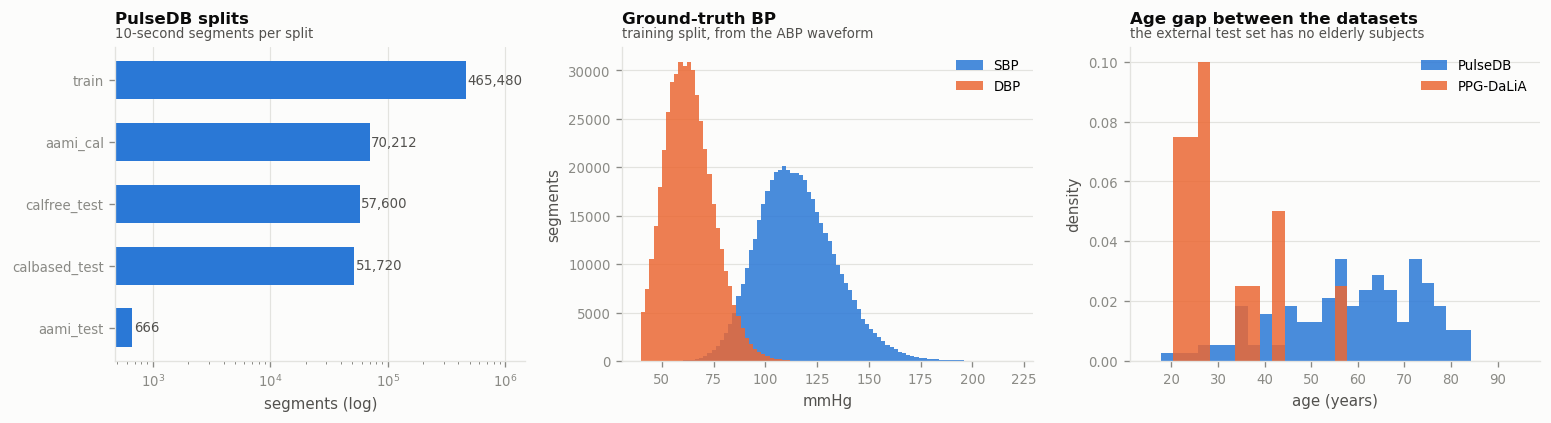

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# a. segment counts per split
ax = axes[0]
o = inv.sort_values("segments")
bars = ax.barh(o.split, o.segments, color=viz.BLUE, height=.62)
for b, v in zip(bars, o.segments):
    ax.text(b.get_width()*1.03, b.get_y()+b.get_height()/2, f"{v:,}",
            va="center", fontsize=8, color=viz.INK_2)
ax.set_xscale("log"); ax.set_xlabel("segments (log)")
ax.set_xlim(right=o.segments.max()*3.2); ax.grid(axis="y", visible=False)
viz.despine(ax); viz.title(ax, "PulseDB splits", "10-second segments per split")

# b. BP label distribution
ax = axes[1]
tr = PulseDBSubset(str(PULSEDB_SUBSETS["train"]))
ax.hist(tr.sbp, bins=90, range=(40,220), color=viz.BLUE, alpha=.85, label="SBP")
ax.hist(tr.dbp, bins=90, range=(40,220), color=viz.ORANGE, alpha=.85, label="DBP")
ax.set_xlabel("mmHg"); ax.set_ylabel("segments"); ax.legend(loc="upper right")
ax.grid(axis="x", visible=False); viz.despine(ax)
viz.title(ax, "Ground-truth BP", "training split, from the ABP waveform")
tr.close()

# c. age: the two datasets side by side
ax = axes[2]
s = PulseDBSubset(str(PULSEDB_SUBSETS["calfree_test"]))
ax.hist(s.age[np.isfinite(s.age)], bins=30, range=(15,95), density=True,
        color=viz.BLUE, alpha=.85, label="PulseDB")
ax.hist(dalia.age, bins=30, range=(15,95), density=True,
        color=viz.ORANGE, alpha=.85, label="PPG-DaLiA")
ax.set_xlabel("age (years)"); ax.set_ylabel("density"); ax.legend(loc="upper right")
ax.grid(axis="x", visible=False); viz.despine(ax)
viz.title(ax, "Age gap between the datasets", "the external test set has no elderly subjects")
s.close()

plt.tight_layout(); save(fig, "comparison/01_datasets_overview.png"); plt.show()

---
## 2. What one segment looks like

Each PulseDB record is 1250 samples — 10 seconds at 125 Hz — with three channels.
The order is not guessable, so it is taken from the authors' own `Generate_Subsets.m`
(line 102: `[Segment.ECG_F, Segment.PPG_F, Segment.ABP_Raw]`) and confirmed below
against the value ranges: two channels normalised to [0, 1], one in mmHg.

In [5]:
s = PulseDBSubset(str(PULSEDB_SUBSETS["calfree_test"]))
probe = s.signals(np.arange(200), channels=(0,1,2))
for i, nm in enumerate(["channel 0", "channel 1", "channel 2"]):
    ch = probe[:, i]
    print(f"{nm}: min={ch.min():8.2f} max={ch.max():8.2f} "
          f"mean={ch.mean():7.2f} std={ch.std():6.2f}")
assert probe[:,0].min() >= -1e-3 and probe[:,0].max() <= 1+1e-3, "ch0 not normalised"
assert probe[:,1].min() >= -1e-3 and probe[:,1].max() <= 1+1e-3, "ch1 not normalised"
assert 20 < probe[:,2].mean() < 200, "ch2 not in mmHg"
print("\nconfirmed: 0=ECG (normalised), 1=PPG (normalised), 2=ABP (mmHg)")

channel 0: min=    0.00 max=    1.00 mean=   0.24 std=  0.19
channel 1: min=    0.00 max=    1.00 mean=   0.36 std=  0.27
channel 2: min=   28.29 max=  204.36 mean=  81.00 std= 23.78

confirmed: 0=ECG (normalised), 1=PPG (normalised), 2=ABP (mmHg)


saved results/figures/pulsedb/01_one_segment.png


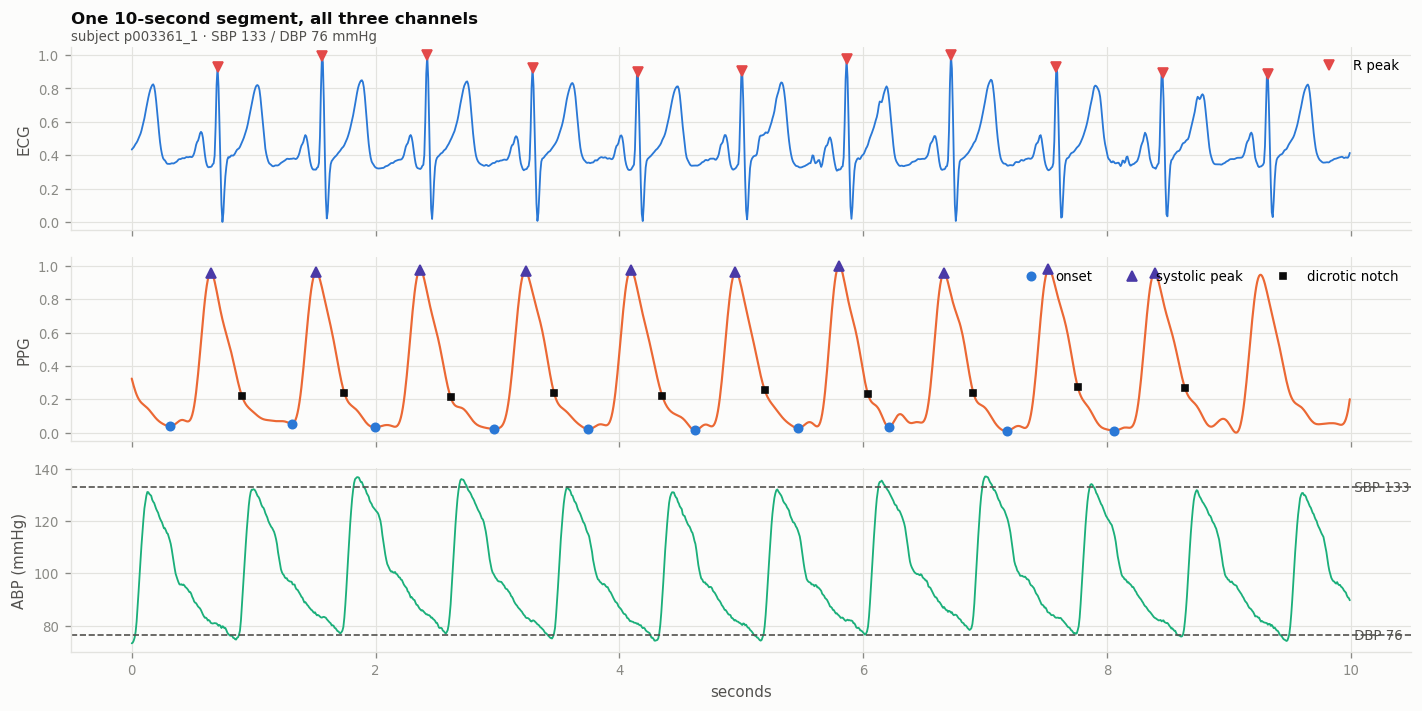

In [6]:
from fiducials import detect_rpeaks, detect_ppg_fiducials, FS

i = 29440
sig = s.signals([i], channels=(0,1,2))[0]
t = np.arange(1250)/FS
rp, rq = detect_rpeaks(sig[0].astype(float))
fid = detect_ppg_fiducials(sig[1].astype(float))

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t, sig[0], color=viz.CH["ecg"], lw=1.1)
axes[0].plot(t[rp], sig[0][rp], "v", ms=6, color=viz.RED, label="R peak")
axes[0].set_ylabel("ECG"); axes[0].legend(loc="upper right")
viz.title(axes[0], "One 10-second segment, all three channels",
          f"subject {s.subject[i]} · SBP {s.sbp[i]:.0f} / DBP {s.dbp[i]:.0f} mmHg")

axes[1].plot(t, sig[1], color=viz.CH["ppg"], lw=1.3)
f_, p_, n_ = fid["foot"], fid["peak"], fid["notch"][fid["notch"]>0]
axes[1].plot(t[f_], sig[1][f_], "o", ms=5, color=viz.BLUE, label="onset")
axes[1].plot(t[p_], sig[1][p_], "^", ms=6, color=viz.VIOLET, label="systolic peak")
axes[1].plot(t[n_], sig[1][n_], "s", ms=4, color=viz.INK, label="dicrotic notch")
axes[1].set_ylabel("PPG"); axes[1].legend(loc="upper right", ncol=3)

axes[2].plot(t, sig[2], color=viz.CH["abp"], lw=1.1)
axes[2].axhline(s.sbp[i], color=viz.INK_2, ls="--", lw=1)
axes[2].axhline(s.dbp[i], color=viz.INK_2, ls="--", lw=1)
axes[2].text(t[-1], s.sbp[i], f" SBP {s.sbp[i]:.0f}", va="center", fontsize=8, color=viz.INK_2)
axes[2].text(t[-1], s.dbp[i], f" DBP {s.dbp[i]:.0f}", va="center", fontsize=8, color=viz.INK_2)
axes[2].set_ylabel("ABP (mmHg)"); axes[2].set_xlabel("seconds")
for a in axes: viz.despine(a)
plt.tight_layout(); save(fig, "pulsedb/01_one_segment.png"); plt.show()

The ABP trace is the label source: PulseDB's authors ran pulse-onset detection over it
and took per-segment SBP/DBP from the peaks and troughs. It is an instrument
measurement, not a human annotation — which is why this dataset has trustworthy targets.

**ABP never becomes a model input.** Only ECG and PPG are written to the processed
arrays; keeping ABP alongside them would be feeding the answer to the model.

---
## 3. Signal quality across the dataset

Quality is not uniform. ECG polarity flips between records, and some segments are
badly corrupted. Rather than silently dropping those — which would quietly inflate
every number reported later — quality is measured, stored as a column, and left for
each experiment to use explicitly.

The most informative check compares the heart rate implied by the ECG with the one
implied by the PPG. They are measuring the same heartbeat, so disagreement means at
least one channel is untrustworthy.

saved results/figures/pulsedb/02_quality_examples.png


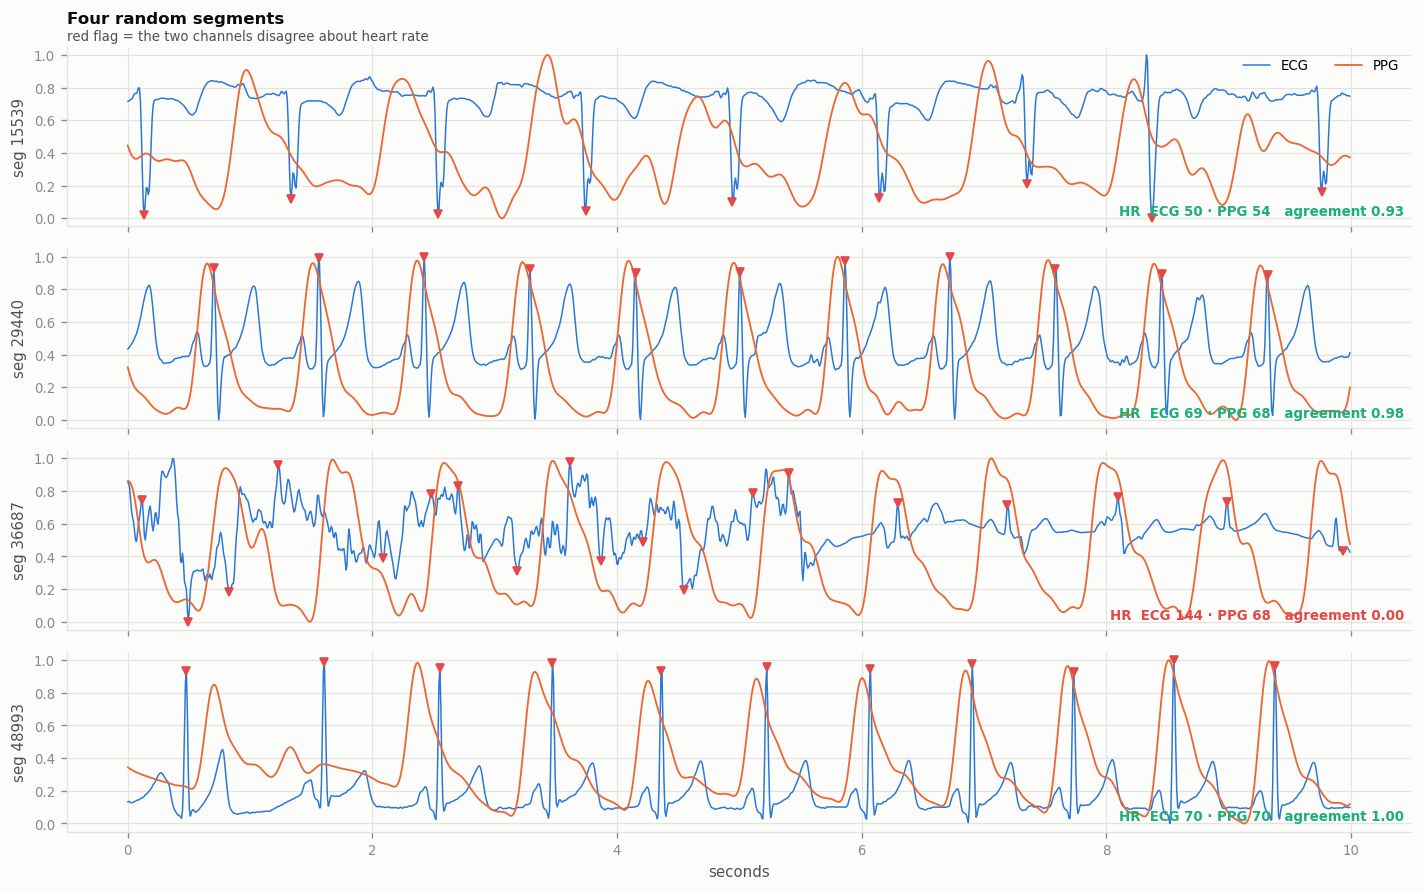

In [7]:
rng = np.random.default_rng(0)
idx = np.sort(rng.choice(s.n, 4, replace=False))
ex = s.signals(idx, channels=(0,1))

fig, axes = plt.subplots(4, 1, figsize=(12, 7.5), sharex=True)
for ax, k, i in zip(axes, range(4), idx):
    ecg, ppg = ex[k,0].astype(float), ex[k,1].astype(float)
    rp, q = detect_rpeaks(ecg); fd = detect_ppg_fiducials(ppg)
    hr_e = 60*FS/np.median(np.diff(rp)) if rp.size>2 else np.nan
    hr_p = 60*FS/np.median(fd["next_foot"]-fd["foot"]) if fd["foot"].size else np.nan
    agree = 1-min(1, abs(hr_e-hr_p)/hr_p) if np.isfinite(hr_e*hr_p) else 0
    ax.plot(t, ecg, color=viz.CH["ecg"], lw=.9, label="ECG")
    ax.plot(t, ppg, color=viz.CH["ppg"], lw=1.1, label="PPG")
    if rp.size: ax.plot(t[rp], ecg[rp], "v", ms=5, color=viz.RED)
    flag = viz.OK if agree > .9 else viz.BAD
    ax.text(.995, .06, f"HR  ECG {hr_e:.0f} · PPG {hr_p:.0f}   agreement {agree:.2f}",
            transform=ax.transAxes, ha="right", fontsize=8,
            color=flag, weight="bold")
    ax.set_ylabel(f"seg {i}"); viz.despine(ax)
axes[0].legend(loc="upper right", ncol=2)
viz.title(axes[0], "Four random segments",
          "red flag = the two channels disagree about heart rate")
axes[-1].set_xlabel("seconds")
plt.tight_layout(); save(fig, "pulsedb/02_quality_examples.png"); plt.show()

In [8]:
# Quality was already computed for every segment during feature extraction.
qual = {}
for name in PULSEDB_SUBSETS:
    f = FEATURES / f"{name}.parquet"
    if f.exists():
        qual[name] = pd.read_parquet(f, columns=["qual_ecg","qual_ppg","qual_hr_agreement"])
q_all = pd.concat(qual, names=["split"]).reset_index(level=0)
print(f"{len(q_all):,} segments\n")
print(q_all.groupby("split")[["qual_ecg","qual_ppg","qual_hr_agreement"]]
      .median().round(3).to_string())
for thr in (0.9, 0.8, 0.5):
    print(f"\nHR agreement >= {thr}: {100*(q_all.qual_hr_agreement>=thr).mean():5.1f}% of segments")

645,678 segments

               qual_ecg  qual_ppg  qual_hr_agreement
split                                               
aami_cal            1.0       1.0              0.995
aami_test           1.0       1.0              0.994
calbased_test       1.0       1.0              0.995
calfree_test        1.0       1.0              0.995
train               1.0       1.0              0.995

HR agreement >= 0.9:  95.1% of segments

HR agreement >= 0.8:  95.9% of segments

HR agreement >= 0.5:  97.0% of segments


saved results/figures/pulsedb/03_quality_distributions.png


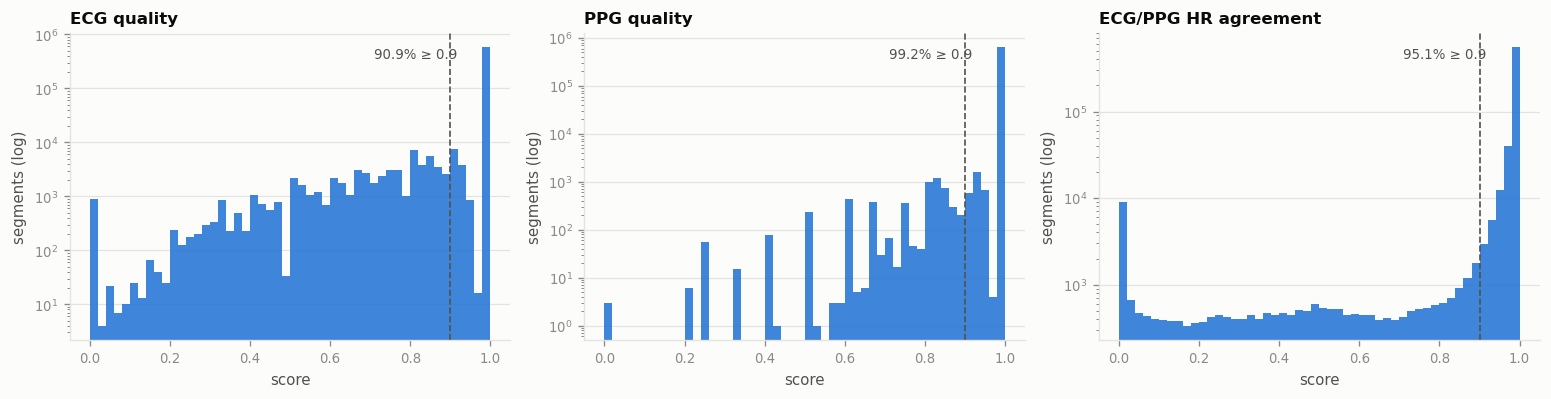

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col, lbl in zip(axes,
        ["qual_ecg","qual_ppg","qual_hr_agreement"],
        ["ECG quality","PPG quality","ECG/PPG HR agreement"]):
    ax.hist(q_all[col], bins=50, range=(0,1), color=viz.BLUE, alpha=.9)
    ax.set_yscale("log"); ax.set_xlabel("score"); ax.set_ylabel("segments (log)")
    ax.grid(axis="x", visible=False); viz.despine(ax)
    good = 100*(q_all[col]>=.9).mean()
    ax.axvline(.9, color=viz.INK_2, ls="--", lw=1)
    ax.text(.88, .92, f"{good:.1f}% ≥ 0.9", transform=ax.transAxes,
            ha="right", fontsize=8, color=viz.INK_2)
    viz.title(ax, lbl)
plt.tight_layout(); save(fig, "pulsedb/03_quality_distributions.png"); plt.show()

PPG is near-perfect almost everywhere; ECG carries the long tail. That matters for
which channel a domain-shift model should lean on — and it is consistent with
PPG-DaLiA, where the wrist PPG is the signal actually available in the field.

---
## 4. Two preprocessing decisions, checked rather than assumed

**Normalisation.** PulseDB already ships band-pass filtered channels, so no extra
filtering is applied — re-filtering a filtered signal only distorts it. What is applied
is per-segment min-max scaling to [0, 1], which is how PulseDB itself normalises and
what keeps PPG-DaLiA comparable, since a wrist sensor's absolute units mean nothing.

**Storage precision.** float32 for every channel would need 6.5 GB. float16 halves that.
Since the stored values live in [0, 1], the question is whether float16's precision is
below the noise floor — measured here rather than assumed.

In [10]:
probe32 = s.signals(np.arange(2000), channels=(0,1)).astype(np.float32)
probe32 = pp.minmax(probe32, axis=-1)
probe16 = probe32.astype(np.float16).astype(np.float32)
err = np.abs(probe32 - probe16)
print(f"float16 round-trip error over {probe32.size:,} samples")
print(f"  max      {err.max():.2e}")
print(f"  mean     {err.mean():.2e}")
print(f"  99.9th   {np.percentile(err, 99.9):.2e}")

# Does it change anything downstream? Re-detect fiducials on both versions.
d32 = [detect_ppg_fiducials(probe32[k,1].astype(float))["foot"] for k in range(300)]
d16 = [detect_ppg_fiducials(probe16[k,1].astype(float))["foot"] for k in range(300)]
same = sum(np.array_equal(a,b) for a,b in zip(d32,d16))
print(f"\nPPG onset detection identical on {same}/300 segments after the round trip")
print(f"storage: float32 {probe32.nbytes/1e6:.1f} MB → float16 {probe32.nbytes/2e6:.1f} MB")

float16 round-trip error over 5,000,000 samples
  max      2.44e-04
  mean     4.50e-05
  99.9th   2.43e-04



PPG onset detection identical on 295/300 segments after the round trip
storage: float32 20.0 MB → float16 10.0 MB


saved results/figures/pulsedb/11_float16_precision.png


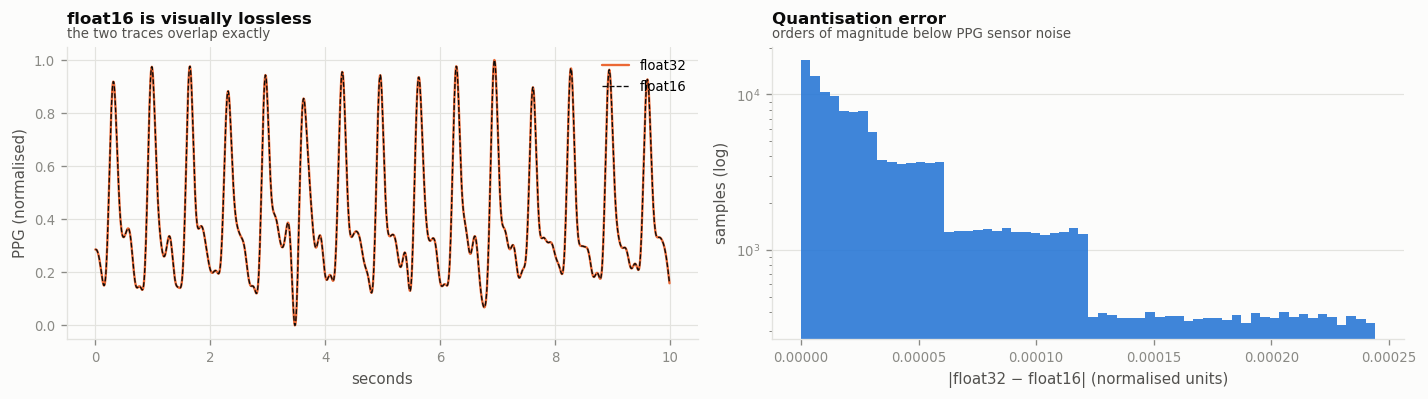

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
ax = axes[0]
seg = probe32[7,1]
ax.plot(t, seg, color=viz.CH["ppg"], lw=1.4, label="float32")
ax.plot(t, probe16[7,1], color=viz.INK, lw=.8, ls="--", label="float16")
ax.set_xlabel("seconds"); ax.set_ylabel("PPG (normalised)"); ax.legend(loc="upper right")
viz.despine(ax); viz.title(ax, "float16 is visually lossless", "the two traces overlap exactly")

ax = axes[1]
ax.hist(err.ravel()[::37], bins=60, color=viz.BLUE, alpha=.9)
ax.set_yscale("log"); ax.set_xlabel("|float32 − float16| (normalised units)")
ax.set_ylabel("samples (log)"); ax.grid(axis="x", visible=False); viz.despine(ax)
viz.title(ax, "Quantisation error", "orders of magnitude below PPG sensor noise")
plt.tight_layout(); save(fig, "pulsedb/11_float16_precision.png"); plt.show()
s.close()

---
## 5. Build the PulseDB waveform arrays

Streamed block by block through a `np.memmap`, so peak memory stays at one block no
matter how large the split. Roughly 18 GB is read and 3.2 GB written; expect this cell
to take some minutes on the first run and to be instant afterwards.

In [12]:
def build_pulsedb(name, force=False):
    out = PROC_PULSEDB / name
    if (out / "signals.npy").exists() and not force:
        sig = np.load(out/"signals.npy", mmap_mode="r")
        print(f"{name:14s} already built  {sig.shape}  {sig.dtype}")
        return
    sub = PulseDBSubset(str(PULSEDB_SUBSETS[name]))
    t0 = time.time()
    def prog(done, total):
        print(f"\r  {name}: {done:>7,}/{total:,}  {time.time()-t0:5.0f}s", end="")
    pp.pulsedb_to_arrays(sub, out, quality=False, progress=prog)
    sub.close()
    sig = np.load(out/"signals.npy", mmap_mode="r")
    print(f"\r{name:14s} {sig.shape} {sig.dtype}  "
          f"{(out/'signals.npy').stat().st_size/1e9:5.2f} GB  {time.time()-t0:.0f}s")

for nm in ["aami_test", "calbased_test", "calfree_test", "aami_cal", "train"]:
    build_pulsedb(nm)
    print(f"   disk free: {free_gb():.1f} GB")

aami_test      (666, 2, 1250) float16   0.00 GB  0s
   disk free: 10.1 GB


  calbased_test:   4,000/51,720      1s

  calbased_test:   8,000/51,720      1s

  calbased_test:  12,000/51,720      2s

  calbased_test:  16,000/51,720      3s

...

  train: 456,000/465,480     79s

  train: 460,000/465,480     80s

  train: 464,000/465,480     81s

  train: 465,480/465,480     81s

train          (465480, 2, 1250) float16   2.33 GB  82s
   disk free: 6.8 GB


In [13]:
# Attach the quality columns computed during feature extraction, and verify alignment.
for name in PULSEDB_SUBSETS:
    out = PROC_PULSEDB / name
    meta = pd.read_parquet(out / "meta.parquet")
    fpath = FEATURES / f"{name}.parquet"
    if not fpath.exists() or "qual_ecg" in meta.columns:
        continue
    feat = pd.read_parquet(fpath, columns=["subject","sbp","qual_ecg","qual_ppg",
                                           "qual_hr_agreement"])
    assert len(feat) == len(meta), f"{name}: length mismatch"
    assert (feat.subject.values == meta.subject.values).all(), f"{name}: order mismatch"
    assert np.allclose(feat.sbp.values, meta.sbp.values, atol=1e-3), f"{name}: label mismatch"
    for c in ["qual_ecg","qual_ppg","qual_hr_agreement"]:
        meta[c] = feat[c].values
    meta.to_parquet(out / "meta.parquet", index=False)
    print(f"{name:14s} quality columns attached, order verified")

train          quality columns attached, order verified


calbased_test  quality columns attached, order verified
calfree_test   quality columns attached, order verified
aami_cal       quality columns attached, order verified
aami_test      quality columns attached, order verified


In [14]:
# Round-trip check: does the processed array still match the source .mat?
name = "aami_test"
sub = PulseDBSubset(str(PULSEDB_SUBSETS[name]))
sig = np.load(PROC_PULSEDB/name/"signals.npy", mmap_mode="r")
lab = np.load(PROC_PULSEDB/name/"labels.npy")
subj = np.load(PROC_PULSEDB/name/"subjects.npy")

k = [0, 17, 333, 665]
src = pp.minmax(sub.signals(k, channels=(0,1)).astype(np.float32), axis=-1)
dst = np.asarray(sig[k], dtype=np.float32)
print(f"max |processed − source| = {np.abs(src-dst).max():.2e}")
print(f"labels match: {np.allclose(lab[k,0], sub.sbp[k]) and np.allclose(lab[k,1], sub.dbp[k])}")
print(f"subjects match: {(subj[k] == sub.subject[k]).all()}")
print(f"shape {sig.shape} · dtype {sig.dtype} · channels (ECG, PPG)")
sub.close()

max |processed − source| = 2.44e-04
labels match: True
subjects match: True
shape (666, 2, 1250) · dtype float16 · channels (ECG, PPG)


---
## 6. PPG-DaLiA → the same shape

For the domain-shift test to mean anything, a PulseDB-trained model has to consume
PPG-DaLiA without modification. So the wrist PPG is resampled 64 → 125 Hz, the chest
ECG 700 → 125 Hz, and both are cut into 10-second windows: identical shape, identical
normalisation, identical channel order.

Windows step every 2 seconds to match the dataset's own heart-rate label cadence.

saved results/figures/ppg_dalia/05_resampling.png


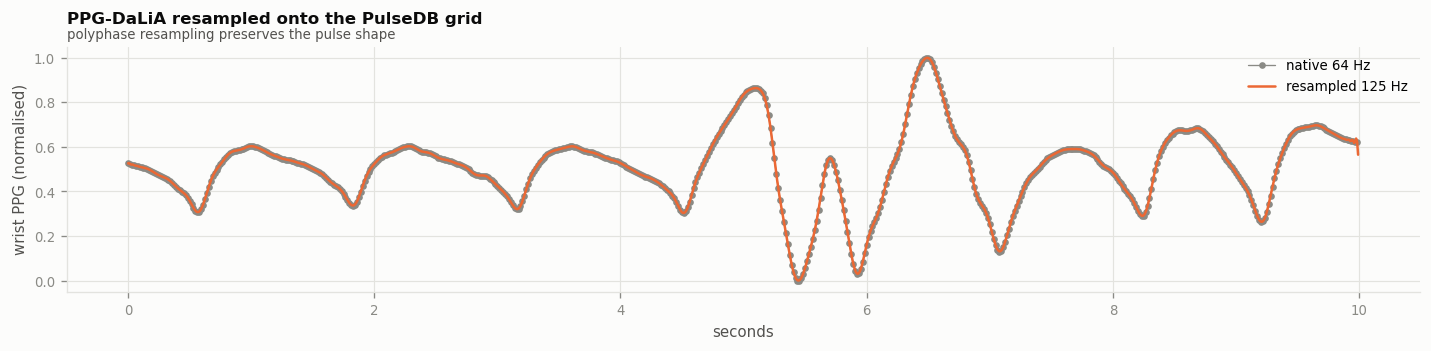

In [15]:
d = np.load(dalia_files[0], allow_pickle=True)
raw_bvp = np.asarray(d["bvp"], float)[:64*10]
up = pp.resample_to(raw_bvp, 64, 125, 1250)
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(np.arange(raw_bvp.size)/64, pp.minmax(raw_bvp), "o-", ms=3, lw=.8,
        color=viz.MUTED, label="native 64 Hz")
ax.plot(np.arange(1250)/125, pp.minmax(up), lw=1.5,
        color=viz.CH["ppg"], label="resampled 125 Hz")
ax.set_xlabel("seconds"); ax.set_ylabel("wrist PPG (normalised)")
ax.legend(loc="upper right"); viz.despine(ax)
viz.title(ax, "PPG-DaLiA resampled onto the PulseDB grid",
          "polyphase resampling preserves the pulse shape")
plt.tight_layout(); save(fig, "ppg_dalia/05_resampling.png"); plt.show()

In [16]:
out_dir = PROC_DALIA / "windows"
if (out_dir / "signals.npy").exists():
    print("already built")
else:
    out_dir.mkdir(parents=True, exist_ok=True)
    all_sig, all_meta = [], []
    for f in dalia_files:
        npz = np.load(f, allow_pickle=True)
        sg, mt = pp.dalia_to_windows(npz)
        mt.insert(0, "subject", Path(f).stem)
        all_sig.append(sg); all_meta.append(mt)
        print(f"  {Path(f).stem:4s} {sg.shape[0]:5d} windows")
    sig = np.concatenate(all_sig); meta = pd.concat(all_meta, ignore_index=True)
    np.save(out_dir/"signals.npy", sig)
    np.save(out_dir/"subjects.npy", meta.subject.to_numpy().astype("U8"))
    meta.to_parquet(out_dir/"meta.parquet", index=False)
    print(f"\n{sig.shape} {sig.dtype}  {(out_dir/'signals.npy').stat().st_size/1e6:.0f} MB")

dsig = np.load(out_dir/"signals.npy", mmap_mode="r")
dmeta = pd.read_parquet(out_dir/"meta.parquet")
print(f"\nPPG-DaLiA windows: {dsig.shape}  ·  {dmeta.subject.nunique()} subjects")
print(f"PulseDB segments : (N, 2, 1250)  — same shape, same channel order")

  S1    4602 windows


  S2    4098 windows


  S3    4366 windows


  S4    4571 windows


  S5    4648 windows


...

  S12   3953 windows


  S13   4564 windows


  S14   4475 windows


  S15   3965 windows



(64682, 2, 1250) float16  323 MB

PPG-DaLiA windows: (64682, 2, 1250)  ·  15 subjects
PulseDB segments : (N, 2, 1250)  — same shape, same channel order


In [17]:
act = (dmeta.groupby("activity_name")
            .agg(windows=("hr","size"), hr=("hr","median"))
            .sort_values("windows", ascending=False))
act["hours"] = act.windows*2/3600
low = dmeta.low_motion.mean()*100
print(act.round(1).to_string())
print(f"\nlow-motion (sitting / driving / working): {low:.1f}% of windows")

               windows     hr  hours
activity_name                       
transient        17486   91.3    9.7
lunch            13556   80.3    7.5
working           8502   74.2    4.7
driving           6838   82.4    3.8
walking           4695   96.1    2.6
sitting           4570   59.0    2.5
cycling           3479  120.2    1.9
stairs            3243  115.8    1.8
table_soccer      2313   85.8    1.3

low-motion (sitting / driving / working): 30.8% of windows


saved results/figures/ppg_dalia/04_activity_and_hr.png


/var/folders/gc/f552rzrn5gx1w_r_06jww1700000gn/T/ipykernel_91979/2945975768.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=order, widths=.55, patch_artist=True,


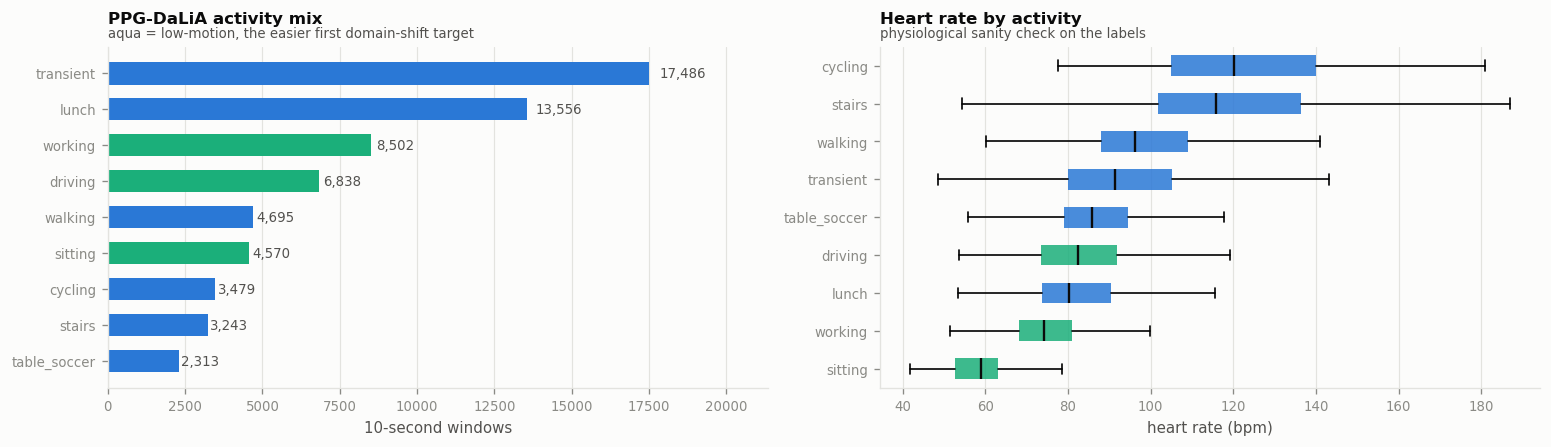

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
o = act.sort_values("windows")
cols = [viz.AQUA if n in ("sitting","driving","working") else viz.BLUE for n in o.index]
bars = ax.barh(o.index, o.windows, color=cols, height=.62)
for b, v in zip(bars, o.windows):
    ax.text(b.get_width()*1.02, b.get_y()+b.get_height()/2, f"{v:,}",
            va="center", fontsize=8, color=viz.INK_2)
ax.set_xlabel("10-second windows"); ax.grid(axis="y", visible=False)
ax.set_xlim(right=o.windows.max()*1.22); viz.despine(ax)
viz.title(ax, "PPG-DaLiA activity mix",
          "aqua = low-motion, the easier first domain-shift target")

ax = axes[1]
order = act.sort_values("hr").index
data = [dmeta.loc[dmeta.activity_name==n, "hr"].dropna() for n in order]
bp = ax.boxplot(data, vert=False, labels=order, widths=.55, patch_artist=True,
                medianprops=dict(color=viz.INK, lw=1.4), showfliers=False)
for patch, n in zip(bp["boxes"], order):
    patch.set_facecolor(viz.AQUA if n in ("sitting","driving","working") else viz.BLUE)
    patch.set_alpha(.85); patch.set_edgecolor("none")
ax.set_xlabel("heart rate (bpm)"); ax.grid(axis="y", visible=False); viz.despine(ax)
viz.title(ax, "Heart rate by activity", "physiological sanity check on the labels")
plt.tight_layout(); save(fig, "ppg_dalia/04_activity_and_hr.png"); plt.show()

---
## 7. How far apart are the two domains?

This is the gap the project has to cross: an ICU/OR finger PPG on a still patient
versus a wrist PPG on someone walking up stairs.

saved results/figures/comparison/02_domain_shift_waveforms.png


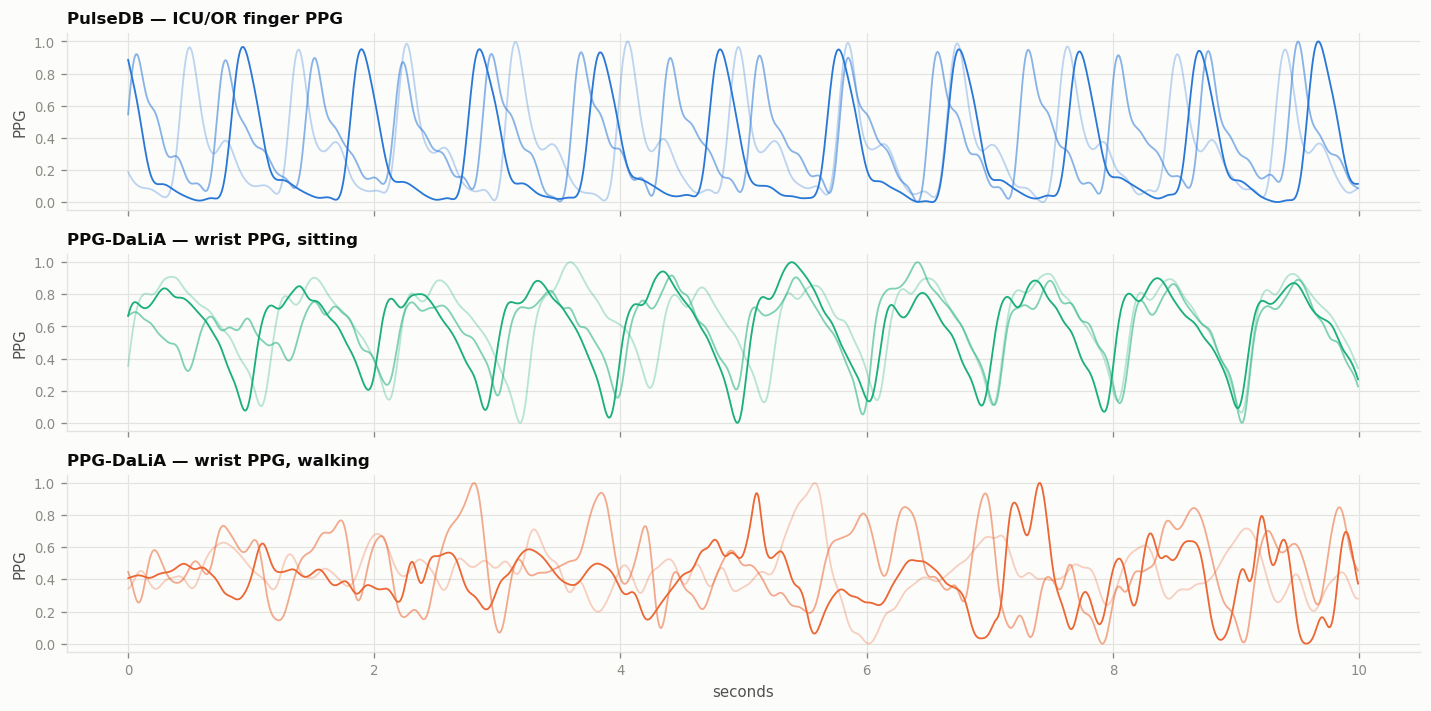

In [19]:
s = PulseDBSubset(str(PULSEDB_SUBSETS["calfree_test"]))
rng = np.random.default_rng(4)
p_idx = np.sort(rng.choice(s.n, 3, replace=False))
p_sig = s.signals(p_idx, channels=(1,))[:,0].astype(float)

sit = dmeta.index[dmeta.activity_name=="sitting"].to_numpy()
walk = dmeta.index[dmeta.activity_name=="walking"].to_numpy()
d_sit = np.asarray(dsig[rng.choice(sit,3,replace=False),1], float)
d_walk = np.asarray(dsig[rng.choice(walk,3,replace=False),1], float)

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True, sharey=True)
for ax, dat, ttl, col in zip(
        axes, [p_sig, d_sit, d_walk],
        ["PulseDB — ICU/OR finger PPG", "PPG-DaLiA — wrist PPG, sitting",
         "PPG-DaLiA — wrist PPG, walking"],
        [viz.BLUE, viz.AQUA, viz.ORANGE]):
    for k, tr_ in enumerate(dat):
        ax.plot(t, tr_ + 0, color=col, lw=1.1, alpha=[1,.55,.3][k])
    ax.set_ylabel("PPG"); viz.despine(ax); viz.title(ax, ttl)
axes[-1].set_xlabel("seconds")
plt.tight_layout(); save(fig, "comparison/02_domain_shift_waveforms.png"); plt.show()

saved results/figures/comparison/03_domain_shift_statistics.png


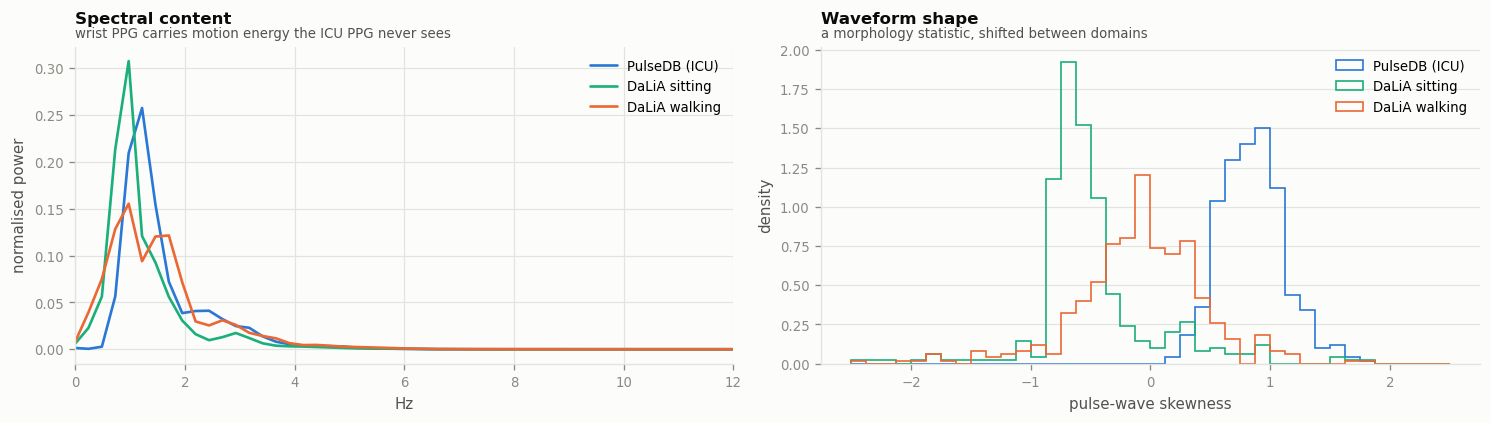

In [20]:
from scipy import signal as sps
def band(x, fs=125):
    f, P = sps.welch(x, fs=fs, nperseg=512)
    return f, P/P.sum()

groups = {"PulseDB (ICU)": np.asarray(s.signals(np.sort(rng.choice(s.n,400,False)),
                                                channels=(1,))[:,0], float),
          "DaLiA sitting": np.asarray(dsig[rng.choice(sit,400,False),1], float),
          "DaLiA walking": np.asarray(dsig[rng.choice(walk,400,False),1], float)}
cols = {"PulseDB (ICU)": viz.BLUE, "DaLiA sitting": viz.AQUA, "DaLiA walking": viz.ORANGE}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
ax = axes[0]
for nm, arr in groups.items():
    P = np.mean([band(x)[1] for x in arr], axis=0)
    f = band(arr[0])[0]
    ax.plot(f, P, color=cols[nm], lw=1.6, label=nm)
ax.set_xlim(0, 12); ax.set_xlabel("Hz"); ax.set_ylabel("normalised power")
ax.legend(loc="upper right"); viz.despine(ax)
viz.title(ax, "Spectral content", "wrist PPG carries motion energy the ICU PPG never sees")

ax = axes[1]
for nm, arr in groups.items():
    sk = [float(pd.Series(x).skew()) for x in arr]
    ax.hist(sk, bins=40, range=(-2.5,2.5), density=True, histtype="step",
            lw=1.8, color=cols[nm], label=nm)
ax.set_xlabel("pulse-wave skewness"); ax.set_ylabel("density")
ax.legend(loc="upper right"); ax.grid(axis="x", visible=False); viz.despine(ax)
viz.title(ax, "Waveform shape", "a morphology statistic, shifted between domains")
plt.tight_layout(); save(fig, "comparison/03_domain_shift_statistics.png"); plt.show()
s.close()

---
## 8. The splits manifest

Which subject is in which split *is* the project's central claim, so it is written to
its own file and the disjointness is asserted in code. If a future change ever lets a
subject cross from train into a test split, this cell raises rather than quietly
producing a better-looking number.

In [21]:
subject_map = {}
for name in PULSEDB_SUBSETS:
    subj = np.load(PROC_PULSEDB/name/"subjects.npy")
    subject_map[name] = sorted(set(subj.tolist()))
subject_map["ppg_dalia"] = sorted(dmeta.subject.unique().tolist())

checks = pp.write_splits_manifest(subject_map, SPLITS/"manifest.json")
print("subjects per split:")
for k, v in subject_map.items():
    print(f"  {k:16s} {len(v):5d}")
print("\noverlap checks:")
for k, v in checks.items():
    print(f"  {k:42s} {v}")
print(f"\nwrote {(SPLITS/'manifest.json').relative_to(ROOT)}")

subjects per split:
  train             1293
  calbased_test     1293
  calfree_test       144
  aami_cal           116
  aami_test          116
  ppg_dalia           15

overlap checks:
  train|calfree_test                         0
  train|aami_cal                             0
  train|aami_test                            0
  calfree_test|calbased_test                 0
  aami_cal&aami_test(expected overlap)       116
  train&calbased_test(expected overlap)      1293

wrote splits/manifest.json


saved results/figures/pulsedb/05_split_overlap.png


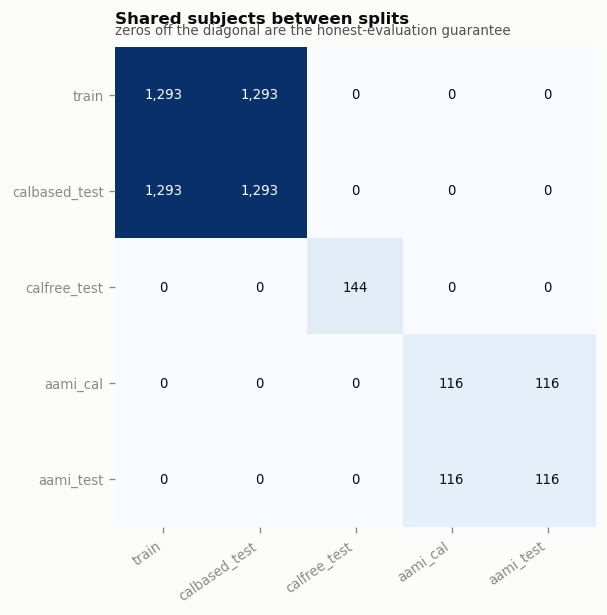

In [22]:
names = list(PULSEDB_SUBSETS)
M = np.zeros((len(names), len(names)), int)
for i,a in enumerate(names):
    for j,b in enumerate(names):
        M[i,j] = len(set(subject_map[a]) & set(subject_map[b]))

fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(M, cmap="Blues", vmin=0, vmax=M.max())
ax.set_xticks(range(len(names)), names, rotation=35, ha="right")
ax.set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{M[i,j]:,}", ha="center", va="center", fontsize=8,
                color="white" if M[i,j] > M.max()*.55 else viz.INK)
ax.grid(False); viz.despine(ax, keep=())
viz.title(ax, "Shared subjects between splits",
          "zeros off the diagonal are the honest-evaluation guarantee")
plt.tight_layout(); save(fig, "pulsedb/05_split_overlap.png"); plt.show()

The two non-zero off-diagonal cells are intentional and must not be read as leakage:

- `aami_cal` ∩ `aami_test` = 116 — the same subjects by design, so a few calibration
  segments can personalise the model before it is scored. Neither appears in `train`.
- `train` ∩ `calbased_test` = 1,293 — calibration-*based* testing means testing on
  known patients. It is an upper bound, never a headline number.

Everything that must be zero is zero.

---
## 9. Final inventory

In [23]:
rows = []
for name in PULSEDB_SUBSETS:
    p = PROC_PULSEDB/name
    sig = np.load(p/"signals.npy", mmap_mode="r")
    meta = pd.read_parquet(p/"meta.parquet")
    rows.append(dict(dataset="PulseDB", split=name, shape=str(sig.shape),
                     dtype=str(sig.dtype), subjects=meta.subject.nunique(),
                     labels="SBP/DBP", mb=round((p/"signals.npy").stat().st_size/1e6)))
p = PROC_DALIA/"windows"
sig = np.load(p/"signals.npy", mmap_mode="r")
rows.append(dict(dataset="PPG-DaLiA", split="windows", shape=str(sig.shape),
                 dtype=str(sig.dtype), subjects=dmeta.subject.nunique(),
                 labels="HR/activity (no BP)",
                 mb=round((p/"signals.npy").stat().st_size/1e6)))
final = pd.DataFrame(rows)
print(final.to_string(index=False))
print(f"\ntotal processed: {final.mb.sum()/1000:.2f} GB   ·   disk free {free_gb():.1f} GB")
print(f"figures written : {len(list(FIG.glob('*.png')))}")

  dataset         split             shape   dtype  subjects              labels   mb
  PulseDB         train (465480, 2, 1250) float16      1293             SBP/DBP 2327
  PulseDB calbased_test  (51720, 2, 1250) float16      1293             SBP/DBP  259
  PulseDB  calfree_test  (57600, 2, 1250) float16       144             SBP/DBP  288
  PulseDB      aami_cal  (70212, 2, 1250) float16       116             SBP/DBP  351
  PulseDB     aami_test    (666, 2, 1250) float16       116             SBP/DBP    3
PPG-DaLiA       windows  (64682, 2, 1250) float16        15 HR/activity (no BP)  323

total processed: 3.55 GB   ·   disk free 6.5 GB
figures written : 10


### What a training script now needs

```python
import numpy as np, pandas as pd
from paths import PROC_PULSEDB

split = PROC_PULSEDB / "train"
X = np.load(split/"signals.npy", mmap_mode="r")   # (N, 2, 1250) float16, 0 bytes of RAM
y = np.load(split/"labels.npy")                   # (N, 2) float32 — SBP, DBP
subj = np.load(split/"subjects.npy")              # for the leakage assertion
meta = pd.read_parquet(split/"meta.parquet")      # demographics + quality columns
```

Cast to float32 inside the batch loader. Never build a split from `subj` without
asserting disjointness against the test split first — `preprocess.write_splits_manifest`
does that check, and `pulsedb_loader.assert_subject_disjoint` does it for loaded subsets.

**Next:** month 4 — 1D-CNN / ResNet1D on these arrays, evaluated under the same
leaky / honest / calibration-free protocols as the classical baselines.